In [39]:
# Hypothesis test 2 — Kitchen return rate vs other categories

kitchen = orders_with_products["category"].eq("Kitchen")

success = [
    orders_with_products.loc[kitchen, "returned"].sum(),
    orders_with_products.loc[~kitchen, "returned"].sum()
]

total = [kitchen.sum(), (~kitchen).sum()]

z_stat, p_value = proportions_ztest(success, total)

print("H0: Kitchen return rate = return rate in all other categories")
print("Test: Two-proportion z-test")
print(f"Kitchen return rate: {success[0]/total[0]*100:.2f}%")
print(f"Other categories return rate: {success[1]/total[1]*100:.2f}%")
print(f"p-value: {p_value:.6f}")

print(
    "Manager takeaway:",
    "Kitchen has a statistically different return rate from other categories."
    if p_value < 0.05
    else "The data does not provide strong evidence that Kitchen's return rate differs from other categories."
)

H0: Kitchen return rate = return rate in all other categories
Test: Two-proportion z-test
Kitchen return rate: 23.75%
Other categories return rate: 6.45%
p-value: 0.000000
Manager takeaway: Kitchen has a statistically different return rate from other categories.


Kitchen Return Hypothesis Test

In [36]:
# Hypothesis Test 1: Houston vs Everyone Else

from statsmodels.stats.proportion import proportions_ztest

houston = customers["city"].eq("Houston")

z, p = proportions_ztest(
    [
        customers.loc[houston, "churned"].sum(),
        customers.loc[~houston, "churned"].sum()
    ],
    [
        houston.sum(),
        (~houston).sum()
    ]
)

print("H0: Houston churn rate = churn rate in all other cities")
print("Test: Two-proportion z-test")
print(f"p-value: {p:.6f}")

if p < 0.05:
    print("Manager takeaway: Houston's churn rate is statistically different from other cities.")
else:
    print("Manager takeaway: There is not strong evidence that Houston differs from other cities.")

H0: Houston churn rate = churn rate in all other cities
Test: Two-proportion z-test
p-value: 0.000000
Manager takeaway: Houston's churn rate is statistically different from other cities.


 Houston vs everyone else — Churn

In [34]:
# Association: Plan vs Churn

plan_churn = customers.groupby("plan")["churned"].agg(["count", "sum"])
plan_churn["churn_rate_%"] = (
    plan_churn["sum"] / plan_churn["count"] * 100
)

print(plan_churn)

print("\nCaution: Plan and churn show an association,")
print("but this does not prove that plan causes churn.")

      count  sum  churn_rate_%
plan                          
free    466   98     21.030043
plus    267   31     11.610487
pro     129   14     10.852713

Caution: Plan and churn show an association,
but this does not prove that plan causes churn.


Association + Causation Caution

In [33]:
# Station C — Center & Spread

order_value = orders["quantity"] * orders["unit_price"]
customer_order_count = orders.groupby("customer_id")["order_id"].count()

print("ORDER VALUE")
print(order_value.describe()[["mean", "50%", "std", "min", "max"]])

print("\nCUSTOMER ORDER COUNT")
print(customer_order_count.describe()[["mean", "50%", "std", "min", "max"]])

ORDER VALUE
mean      91.213695
50%       78.000000
std       86.954663
min       15.000000
max     1780.000000
dtype: float64

CUSTOMER ORDER COUNT
mean     3.981199
50%      4.000000
std      2.275108
min      1.000000
max     25.000000
Name: order_id, dtype: float64


Measures of center and spread
This covers:
Order value
Customer order-count
Mean, median, standard deviation, min, max, quartiles

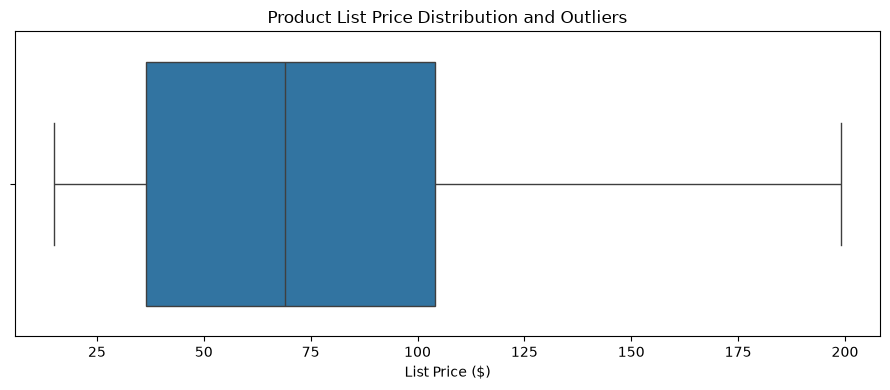

In [30]:
# 6. Product price distribution and outliers

plt.figure(figsize=(9, 4))
sns.boxplot(x=products["list_price"])
plt.title("Product List Price Distribution and Outliers")
plt.xlabel("List Price ($)")
plt.tight_layout()
plt.show()

6. Price Distribution + Outliers

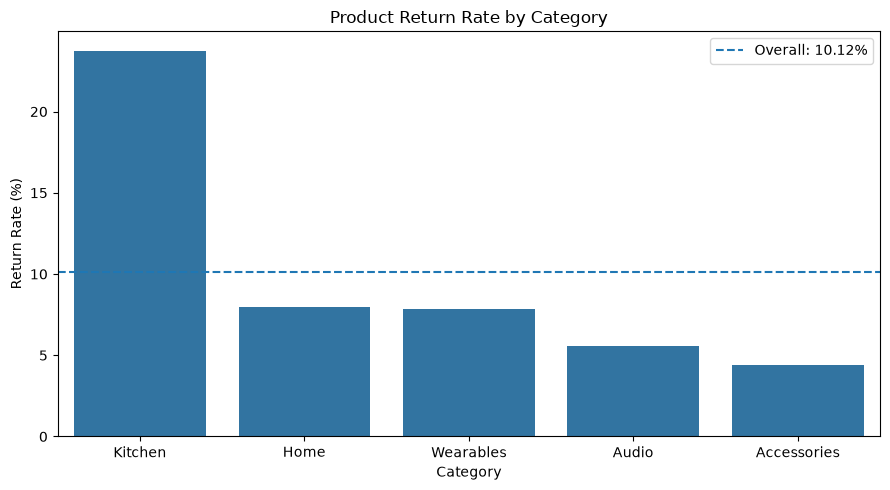

In [29]:
# 5. Category returns

plt.figure(figsize=(9, 5))
sns.barplot(data=return_by_category.reset_index(),
            x="category", y="return_rate_pct")
plt.axhline(overall_return_rate, linestyle="--",
            label=f"Overall: {overall_return_rate:.2f}%")
plt.title("Product Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

5. Category Return Plot

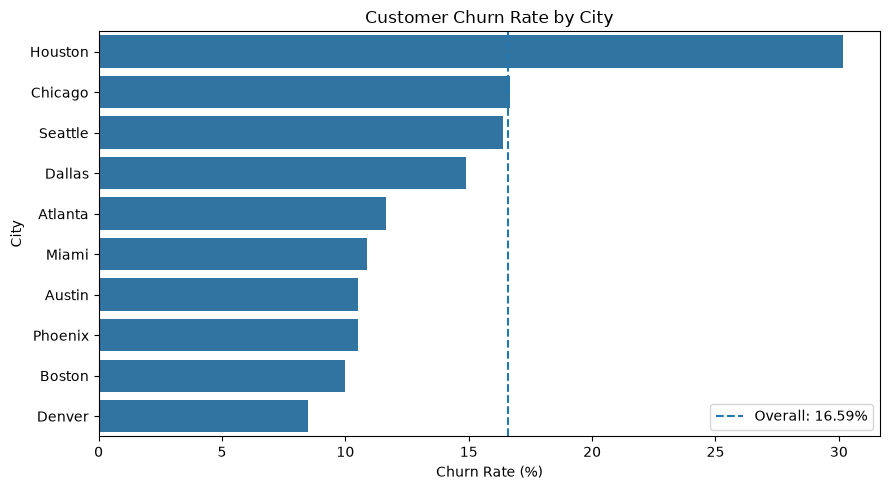

In [28]:
# 4. City churn

plt.figure(figsize=(9, 5))
sns.barplot(data=churn_by_city.reset_index(), x="churn_rate_pct", y="city")
plt.axvline(overall_churn_rate, linestyle="--",
            label=f"Overall: {overall_churn_rate:.2f}%")
plt.title("Customer Churn Rate by City")
plt.xlabel("Churn Rate (%)")
plt.ylabel("City")
plt.legend()
plt.tight_layout()
plt.show()

4. City Churn Plot

In [27]:
# 3. Orphan orders

orphan_customer = ~orders["customer_id"].isin(customers["customer_id"])
orphan_product = ~orders["product_id"].isin(products["product_id"])

print("Orphan orders - customer:", orphan_customer.sum())
print("Orphan orders - product:", orphan_product.sum())

print("Rule: Keep orphan records in the raw data, but exclude them from linked EDA.")

Orphan orders - customer: 25
Orphan orders - product: 0
Rule: Keep orphan records in the raw data, but exclude them from linked EDA.


3. Orphan records — count/document + rule

In [26]:
# 2. Duplicate customers

duplicate_count = customers.duplicated("customer_id", keep=False).sum()

print("Duplicate customer rows:", duplicate_count)
print("Rule: Keep the first valid customer record and flag duplicates if found.")

Duplicate customer rows: 0
Rule: Keep the first valid customer record and flag duplicates if found.


2. Duplicate customers — count/document + rule

In [25]:
# 1. Clean and flag dirty email/phone values

customers["email_clean"] = customers["email"].astype("string").str.strip().str.lower()
customers["email_valid"] = customers["email_clean"].str.match(
    r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$", na=False
)

customers["phone_clean"] = customers["phone"].astype("string").str.replace(
    r"\D", "", regex=True
)
customers["phone_valid"] = customers["phone_clean"].str.len().eq(10)

print("Invalid/missing emails:", (~customers["email_valid"]).sum())
print("Invalid/missing phones:", (~customers["phone_valid"]).sum())

Invalid/missing emails: 20
Invalid/missing phones: 815


1. Dirty email / phone — clean + flag